In [1]:
# Installation des librairies nécessaires
!pip install -q segmentation-models-pytorch datasets tqdm


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
# --- 1. Importations ---
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp


# On s'assure qu'on est bien dans le dossier qui contient 'src'
# Si ton notebook est à la racine, ceci suffit :
sys.path.append(os.getcwd()) 

# Maintenant les imports marcheront nativement !
#from src.data_loader import load_and_split_data, create_loaders
from src.models import get_model
from src.train_utils import train_model
from src.viz import plot_history, visualize_results
from datasets import load_dataset
from src.data_loader import prepare_dataloaders

print("✅ Imports fonctionnels depuis le dossier local.")

✅ Imports fonctionnels depuis le dossier local.


In [3]:
# 1. Chargement brut
raw_dataset = load_dataset("SerdarHelli/SegmentationOfTeethPanoramicXRayImages")

# 2. Transformation et mise en Loaders (Automatique via src)
# Mise à jour de l'appel (on récupère 3 loaders maintenant)
train_loader, val_loader, test_loader = prepare_dataloaders(raw_dataset['train'], batch_size=8)

print(f"Nombre de batchs train : {len(train_loader)} ({len(train_loader.dataset)} images)")
print(f"Nombre de batchs val   : {len(val_loader)} ({len(val_loader.dataset)} images)")
print(f"Nombre de batchs test  : {len(test_loader)} ({len(test_loader.dataset)} images)")

Nombre de batchs train : 12 (96 images)
Nombre de batchs val   : 2 (10 images)
Nombre de batchs test  : 2 (10 images)


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de : {device}")
model = get_model(mode="vanilla", device=device)

Utilisation de : cpu


In [8]:
# 2. Configuration de la perte et de l'optimiseur
# On utilise DiceLoss qui est très efficace pour les dents
criterion = smp.losses.DiceLoss(mode='binary')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)



In [10]:
# 3. Lancement de l'entraînement
print("Début de l'entraînement...")
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=2 # Tu peux augmenter à 50 plus tard
)



Début de l'entraînement...


Training: 100%|████████| 2/2 [03:51<00:00, 115.67s/it, Loss=0.3909, Val=0.4044]


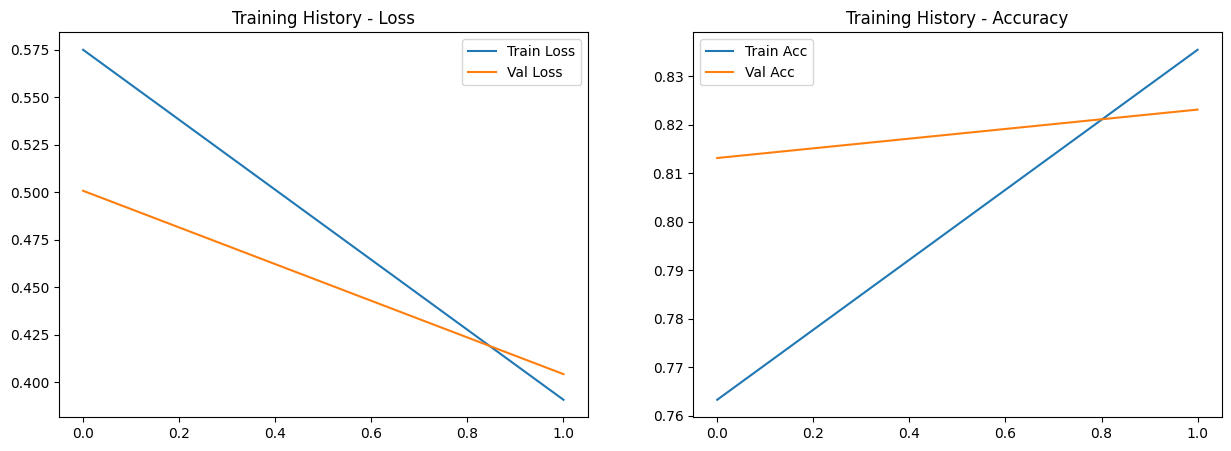

In [11]:
# 4. Affichage des courbes
from src.viz import plot_history
plot_history(history)

In [ ]:
# Charge le modèle et lui injecte tes poids sauvegardés automatiquement
model = get_model(
    mode="vanilla", 
    model_path="weights/segmentation_final.pth", 
    device=device
)